# Proyecto 1 — Optimización Operativa & Análisis de Tiempos de Servicio

Este notebook cubre el **Punto 3 (Requerimientos Técnicos — Ingesta, Limpieza y Feature Engineering)**
del enunciado, y prepara los insumos necesarios para los entregables del Punto 4
(Dashboard en Power BI y Documento de Decisión de Negocio con análisis de Pareto).

**Dataset:** `DS_DAP_P1.csv` — 2000 tickets de servicio al cliente.

**Contenido:**
1. Carga y exploración inicial de datos
2. Limpieza de datos (timestamps invertidos, duraciones negativas, nulos)
3. Feature Engineering (Wait Time, Resolution Time, Total Cycle Time)
4. Flags de cumplimiento de SLA
5. Franjas horarias (Time Buckets)
6. Métricas clave (% SLA Compliance, % FCR, AHT, Promedio Móvil 7 días)
7. Análisis de Pareto (20% de categorías → 80% de retrasos)
8. Heatmap de volumen por hora/día y ranking de agentes
9. Exportación del dataset limpio (para Power BI / SQL)


## 1. Carga y exploración inicial

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('DS_DAP_P1.csv', parse_dates=['created_at', 'resolved_at'])
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 2,000 | Columnas: 23


,ticket_id,created_at,resolved_at,channel,category,subcategory,priority,status,sentiment,product,customer_plan,region,language,assigned_agent,message,resolution_note,resolution_time_hrs,csat_score,first_response_time_hrs,reopened,escalated,num_interactions,customer_tenure_days
0,TKT-00001,2025-06-01 07:35:00,NaT,email,Feature Request,Export options,Low,In Progress,Neutral,TaskBoard,Enterprise,South Asia,English,Agent_001 (Priya S),Is there any plan to expose an API for the rep...,Issue fixed by agent,NaN,NaN,2.4,False,False,10,542
1,TKT-00002,2024-02-16 14:49:00,2024-02-17 08:07:00,whatsapp,Refund / Return,Full refund,High,Escalated,Negative,DataDash,Enterprise,South Asia,Arabic,Agent_006 (Raj P),I was overcharged and would like a partial ref...,Escalated to engineering,17.3,NaN,12.9,False,True,8,778
2,TKT-00003,2024-11-18 13:41:00,NaT,helpdesk_portal,Technical Issue,Feature not working,Critical,In Progress,Negative,DataDash,Free,Southeast Asia,Spanish,Agent_004 (Omar F),My data isn't syncing across devices. Last suc...,Issue fixed by agent,NaN,NaN,8.8,False,False,3,1044
3,TKT-00004,2024-01-12 10:43:00,NaT,chat,Account Access,Account deletion,High,In Progress,Very Negative,CloudSync Pro,Professional,Southeast Asia,Hindi,Agent_005 (Sophie M),I'm having trouble with 2FA — the codes aren't...,Issue fixed by agent,NaN,NaN,20.9,False,False,11,1040
4,TKT-00005,2024-11-10 14:03:00,2024-11-13 12:45:00,chat,Feature Request,Dark mode,Low,Resolved,Very Negative,TaskBoard,Free,South Asia,English,Agent_009 (Yuki T),It would be really helpful if SecureVault supp...,Pending customer,70.7,1.9,18.2,False,False,12,639


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ticket_id                2000 non-null   object        
 1   created_at               2000 non-null   datetime64[ns]
 2   resolved_at              1451 non-null   datetime64[ns]
 3   channel                  2000 non-null   object        
 4   category                 2000 non-null   object        
 5   subcategory              2000 non-null   object        
 6   priority                 2000 non-null   object        
 7   status                   2000 non-null   object        
 8   sentiment                2000 non-null   object        
 9   product                  2000 non-null   object        
 10  customer_plan            2000 non-null   object        
 11  region                   2000 non-null   object        
 12  language                 2000 non-

In [23]:
# Resumen de nulos por columna
nulos = df.isna().sum().to_frame('n_nulos')
nulos['pct'] = (nulos['n_nulos'] / len(df) * 100).round(1)
nulos[nulos['n_nulos'] > 0].sort_values('n_nulos', ascending=False)


,n_nulos,pct
csat_score,664,33.2
resolved_at,549,27.4
resolution_time_hrs,549,27.4
resolution_note,79,4.0
first_response_time_hrs,76,3.8


## 2. Limpieza de datos

Reglas de negocio del esquema (Punto 2 del enunciado):

- $T_1$ = `created_at` (Entrada)
- $T_2$ = `created_at + first_response_time_hrs` (Inicio de atención)
- $T_3$ = `resolved_at` (Cierre)

Se detectan y corrigen:
- Timestamps invertidos ($T_3 < T_1$)
- Duraciones negativas (`resolution_time_hrs`, `first_response_time_hrs`)
- Tickets sin cierre (`resolved_at` nulo) — se conservan como "abiertos", no se eliminan
- Categóricas con espacios/inconsistencias de formato


In [24]:
df_clean = df.copy()

# --- 2.1 Timestamps invertidos: resolved_at < created_at ---
mask_inverted = df_clean['resolved_at'].notna() & (df_clean['resolved_at'] < df_clean['created_at'])
print(f"Tickets con T3 < T1 (timestamps invertidos): {mask_inverted.sum()}")

# --- 2.2 Duraciones negativas ---
mask_neg_res = df_clean['resolution_time_hrs'] < 0
mask_neg_frt = df_clean['first_response_time_hrs'] < 0
print(f"resolution_time_hrs negativo: {mask_neg_res.sum()}")
print(f"first_response_time_hrs negativo: {mask_neg_frt.sum()}")

# --- 2.3 Comparación de Inconsistencia (Wait Time vs Handling Time) ---
# Se evalúa estrictamente solo si ambas métricas existen en el ticket
mask_frt_gt_res = (
    df_clean['first_response_time_hrs'].notna()
    & df_clean['resolution_time_hrs'].notna()
    & (df_clean['first_response_time_hrs'] > df_clean['resolution_time_hrs'])
)
print(f"first_response_time_hrs > resolution_time_hrs: {mask_frt_gt_res.sum()}")


Tickets con T3 < T1 (timestamps invertidos): 0
resolution_time_hrs negativo: 0
first_response_time_hrs negativo: 0
first_response_time_hrs > resolution_time_hrs: 133


In [25]:
# Mapeo y anulación de registros defectuosos
invalid_mask = mask_inverted | mask_neg_res | mask_neg_frt | mask_frt_gt_res
print(f"Total de registros con alguna inconsistencia de tiempos: {invalid_mask.sum()} "
      f"({invalid_mask.sum()/len(df_clean)*100:.1f}%)")

df_clean.loc[mask_inverted, 'resolved_at'] = pd.NaT
df_clean.loc[mask_neg_res, 'resolution_time_hrs'] = np.nan
df_clean.loc[mask_neg_frt, 'first_response_time_hrs'] = np.nan
df_clean.loc[mask_frt_gt_res, ['resolution_time_hrs', 'first_response_time_hrs']] = np.nan

df_clean['is_inconsistent_time'] = invalid_mask


Total de registros con alguna inconsistencia de tiempos: 133 (6.7%)


In [26]:
# --- 2.4 Normalizar texto RESPETANDO los Nulos (NaN) ---
cat_cols = ['channel', 'category', 'subcategory', 'priority', 'status',
            'sentiment', 'product', 'customer_plan', 'region', 'language']

for c in cat_cols:
    if c in df_clean.columns:
        # Aplica strip solo a los valores no nulos para no convertir NaN en la palabra 'nan'
        df_clean[c] = df_clean[c].where(df_clean[c].isna(), df_clean[c].astype(str).str.strip())

# --- 2.5 csat_score fuera de rango (debe ser 1-5) ---
if 'csat_score' in df_clean.columns:
    mask_csat_bad = df_clean['csat_score'].notna() & ~df_clean['csat_score'].between(1, 5)
    print(f"csat_score fuera de rango [1,5]: {mask_csat_bad.sum()}")
    df_clean.loc[mask_csat_bad, 'csat_score'] = np.nan

# --- 2.6 Duplicados por ticket_id ---
dups = df_clean['ticket_id'].duplicated().sum()
print(f"ticket_id duplicados: {dups}")
df_clean = df_clean.drop_duplicates(subset='ticket_id')

print(f"\nFilas tras limpieza: {len(df_clean):,}")


csat_score fuera de rango [1,5]: 0
ticket_id duplicados: 0

Filas tras limpieza: 2,000


## 3. Feature Engineering

$$Wait\ Time = T_2 - T_1 \quad\quad Resolution\ Time = T_3 - T_2 \quad\quad Total\ Cycle\ Time = T_3 - T_1$$

En este dataset, `first_response_time_hrs` ya representa $T_2 - T_1$ (Wait Time) y
`resolution_time_hrs` ya representa $T_3 - T_1$ (Total Cycle Time). A partir de ambos
se deriva `resolution_time_only_hrs` = $T_3 - T_2$.


In [27]:
# 1. Asignaciones de métricas
df_clean['wait_time_hrs'] = df_clean['first_response_time_hrs']
df_clean['total_cycle_time_hrs'] = df_clean['resolution_time_hrs']
df_clean['resolution_only_hrs'] = df_clean['total_cycle_time_hrs'] - df_clean['wait_time_hrs']

# 2. Manejo seguro de NaN en to_timedelta (rellena temporalmente nulos con 0 para la suma temporal)
df_clean['first_response_at'] = df_clean['created_at'] + pd.to_timedelta(
    df_clean['wait_time_hrs'].fillna(0), unit='h'
)

# 3. Restaurar Nulos si el ticket originalmente NO tuvo respuesta inicial (opcional pero recomendado)
df_clean.loc[df_clean['wait_time_hrs'].isna(), 'first_response_at'] = pd.NaT

# 4. Visualización
df_clean[['created_at', 'first_response_at', 'resolved_at',
          'wait_time_hrs', 'resolution_only_hrs', 'total_cycle_time_hrs']].head()


,created_at,first_response_at,resolved_at,wait_time_hrs,resolution_only_hrs,total_cycle_time_hrs
0,2025-06-01 07:35:00,2025-06-01 09:59:00,NaT,2.4,NaN,NaN
1,2024-02-16 14:49:00,2024-02-17 03:43:00,2024-02-17 08:07:00,12.9,4.4,17.3
2,2024-11-18 13:41:00,2024-11-18 22:29:00,NaT,8.8,NaN,NaN
3,2024-01-12 10:43:00,2024-01-13 07:37:00,NaT,20.9,NaN,NaN
4,2024-11-10 14:03:00,2024-11-11 08:15:00,2024-11-13 12:45:00,18.2,52.5,70.7


## 4. Flags de cumplimiento de SLA

Se define un SLA objetivo de **Total Cycle Time** por prioridad (supuesto de negocio,
ajustable según el acuerdo real de la organización):

| Prioridad | SLA objetivo (horas) |
|---|---|
| Critical | 8 |
| High | 24 |
| Medium | 48 |
| Low | 72 |


In [28]:
sla_targets = {'Critical': 8, 'High': 24, 'Medium': 48, 'Low': 72}
df_clean['sla_target_hrs'] = df_clean['priority'].map(sla_targets)

# Cumple SLA solo si el ticket está cerrado y su ciclo total fue <= al objetivo
df_clean['sla_met'] = np.where(
    df_clean['total_cycle_time_hrs'].notna(),
    df_clean['total_cycle_time_hrs'] <= df_clean['sla_target_hrs'],
    np.nan
)

sla_compliance = df_clean['sla_met'].dropna().mean() * 100
print(f"% SLA Compliance global (tickets cerrados y válidos): {sla_compliance:.1f}%")


% SLA Compliance global (tickets cerrados y válidos): 37.9%


## 5. Franjas horarias (Time Buckets)

In [29]:
def time_bucket(hour):
    if 6 <= hour < 12:
        return 'Mañana (06-12)'
    elif 12 <= hour < 18:
        return 'Tarde (12-18)'
    elif 18 <= hour < 24:
        return 'Noche (18-24)'
    else:
        return 'Madrugada (00-06)'

df_clean['created_hour'] = df_clean['created_at'].dt.hour
df_clean['created_dow'] = df_clean['created_at'].dt.day_name()
df_clean['time_bucket'] = df_clean['created_hour'].apply(time_bucket)
df_clean['created_date'] = df_clean['created_at'].dt.date

df_clean[['created_at', 'created_hour', 'created_dow', 'time_bucket']].head()


,created_at,created_hour,created_dow,time_bucket
0,2025-06-01 07:35:00,7,Sunday,Mañana (06-12)
1,2024-02-16 14:49:00,14,Friday,Tarde (12-18)
2,2024-11-18 13:41:00,13,Monday,Tarde (12-18)
3,2024-01-12 10:43:00,10,Friday,Mañana (06-12)
4,2024-11-10 14:03:00,14,Sunday,Tarde (12-18)


## 6. Métricas clave (equivalentes a las medidas DAX del Punto 3)

In [30]:
# % SLA Compliance
pct_sla = df_clean['sla_met'].dropna().mean() * 100

# % First Contact Resolution (FCR)
pct_fcr = df_clean['first_contact_resolved'].mean() * 100 if 'first_contact_resolved' in df_clean.columns else None

# Average Handling Time (AHT) -> tiempo de resolución (T3-T2) promedio
aht = df_clean['resolution_only_hrs'].mean()

print(f"% SLA Compliance : {pct_sla:.1f}%")
if pct_fcr is not None:
    print(f"% FCR            : {pct_fcr:.1f}%")
print(f"AHT (T3-T2, hrs) : {aht:.2f}")
print(f"Wait Time medio  : {df_clean['wait_time_hrs'].mean():.2f} hrs")
print(f"CSAT promedio    : {df_clean['csat_score'].mean():.2f} / 5")


% SLA Compliance : 37.9%
AHT (T3-T2, hrs) : 51.81
Wait Time medio  : 11.66 hrs
CSAT promedio    : 2.71 / 5


In [31]:
# Nota: el dataset no incluye 'first_contact_resolved'; se aproxima FCR con num_interactions == 1
df_clean['fcr_proxy'] = df_clean['num_interactions'] == 1
pct_fcr_proxy = df_clean['fcr_proxy'].mean() * 100
print(f"% FCR (proxy: num_interactions == 1): {pct_fcr_proxy:.1f}%")


% FCR (proxy: num_interactions == 1): 8.5%


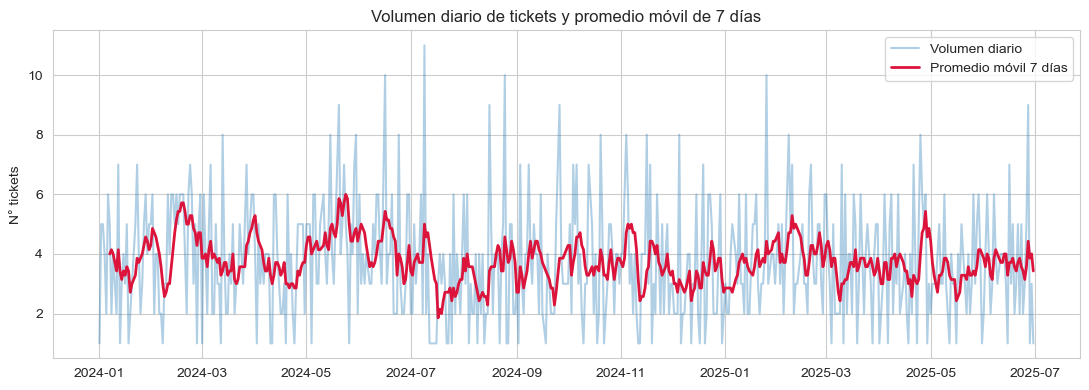

In [32]:
# Promedio móvil de 7 días del volumen diario de tickets creados
daily_volume = df_clean.groupby('created_date').size().rename('tickets').to_frame()
daily_volume.index = pd.to_datetime(daily_volume.index)
daily_volume = daily_volume.sort_index()
daily_volume['ma_7d'] = daily_volume['tickets'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily_volume.index, daily_volume['tickets'], alpha=0.35, label='Volumen diario')
ax.plot(daily_volume.index, daily_volume['ma_7d'], color='crimson', linewidth=2, label='Promedio móvil 7 días')
ax.set_title('Volumen diario de tickets y promedio móvil de 7 días')
ax.set_ylabel('N° tickets')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Análisis de Pareto — Categorías que concentran los retrasos

Para el **Documento de Decisión de Negocio**: se identifica qué porcentaje de categorías
concentra el 80% del tiempo total de retraso (definido como horas por sobre el SLA objetivo).


In [33]:
df_clean['delay_hrs'] = (df_clean['total_cycle_time_hrs'] - df_clean['sla_target_hrs']).clip(lower=0)

pareto = (
    df_clean.dropna(subset=['delay_hrs'])
    .groupby('category')['delay_hrs']
    .sum()
    .sort_values(ascending=False)
    .to_frame('total_delay_hrs')
)
pareto['pct_delay'] = pareto['total_delay_hrs'] / pareto['total_delay_hrs'].sum() * 100
pareto['cum_pct_delay'] = pareto['pct_delay'].cumsum()
pareto


,total_delay_hrs,pct_delay,cum_pct_delay
category,,,
Billing,5546.5,22.065610,22.065610
Technical Issue,4722.1,18.785904,40.851514
Account Access,3669.8,14.599545,55.451059
Delivery / Shipping,3175.4,12.632676,68.083735
Feature Request,3054.0,12.149711,80.233446
Refund / Return,2058.3,8.188523,88.421970
General Inquiry,1647.5,6.554240,94.976210
Complaint,1262.8,5.023790,100.000000


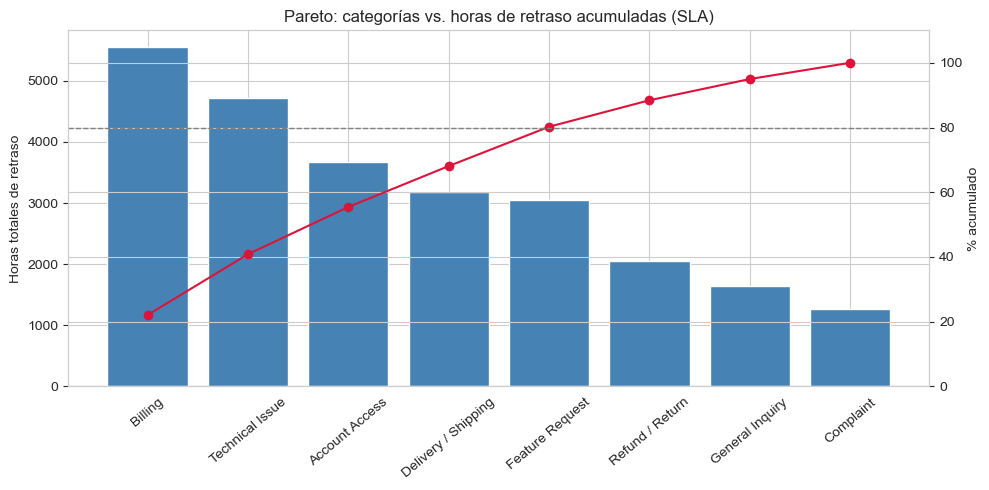

Categorías necesarias para explicar el 80% del retraso: 5 de 8 (62% de las categorías)


In [34]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(pareto.index, pareto['total_delay_hrs'], color='steelblue')
ax1.set_ylabel('Horas totales de retraso')
ax1.tick_params(axis='x', rotation=40)

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['cum_pct_delay'], color='crimson', marker='o')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('% acumulado')
ax2.set_ylim(0, 110)

plt.title('Pareto: categorías vs. horas de retraso acumuladas (SLA)')
plt.tight_layout()
plt.show()

n_cat_80 = (pareto['cum_pct_delay'] <= 80).sum() + 1
print(f"Categorías necesarias para explicar el 80% del retraso: {n_cat_80} de {len(pareto)} "
      f"({n_cat_80/len(pareto)*100:.0f}% de las categorías)")


## 8. Heatmap de volumen por hora del día / día de la semana

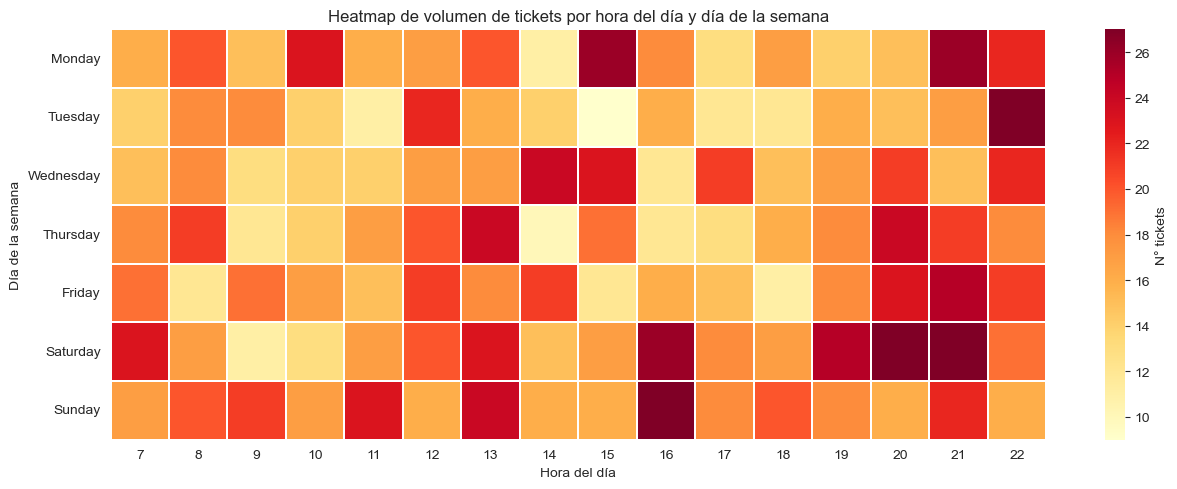

In [35]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat_data = (
    df_clean.groupby(['created_dow', 'created_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(dow_order)
)

plt.figure(figsize=(13, 5))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'N° tickets'})
plt.title('Heatmap de volumen de tickets por hora del día y día de la semana')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()


### Ranking de agentes por tiempo de resolución (AHT)

In [36]:
agent_rank = (
    df_clean.dropna(subset=['resolution_only_hrs'])
    .groupby('assigned_agent')
    .agg(n_tickets=('ticket_id', 'count'),
         aht_hrs=('resolution_only_hrs', 'mean'),
         csat_prom=('csat_score', 'mean'),
         pct_sla=('sla_met', 'mean'))
    .assign(pct_sla=lambda d: d['pct_sla'] * 100)
    .sort_values('aht_hrs', ascending=False)
)
agent_rank.round(2).head(15)


,n_tickets,aht_hrs,csat_prom,pct_sla
assigned_agent,,,,
Agent_002 (James T),135,56.41,2.77,39.26
Agent_007 (Elena V),127,56.07,2.87,37.01
Agent_009 (Yuki T),142,53.93,2.71,36.62
Agent_006 (Raj P),134,52.08,2.71,40.30
Agent_005 (Sophie M),142,51.70,2.59,37.32
Agent_003 (Lena K),138,51.68,2.60,38.41
Agent_004 (Omar F),144,49.85,2.62,34.72
Agent_001 (Priya S),165,49.25,2.72,40.61
Agent_008 (Daniel N),132,46.08,2.84,39.39


### Ranking de categorías por tiempo de resolución

In [37]:
category_rank = (
    df_clean.dropna(subset=['resolution_only_hrs'])
    .groupby('category')
    .agg(n_tickets=('ticket_id', 'count'),
         aht_hrs=('resolution_only_hrs', 'mean'),
         pct_sla=('sla_met', 'mean'))
    .assign(pct_sla=lambda d: d['pct_sla'] * 100)
    .sort_values('aht_hrs', ascending=False)
)
category_rank.round(2)


,n_tickets,aht_hrs,pct_sla
category,,,
Delivery / Shipping,125,57.48,38.40
Feature Request,143,56.47,32.87
General Inquiry,74,55.71,37.84
Complaint,62,53.28,45.16
Billing,293,50.97,36.86
Account Access,188,50.79,36.70
Refund / Return,118,49.30,40.68
Technical Issue,256,47.84,41.02


## 9. Exportación del dataset limpio

Se exporta el dataset limpio con las nuevas columnas (features, flags, buckets) listo
para ser cargado en Power BI / SQL como base para `Fact_ServiceEvents`
(esquema dimensional Kimball del Punto 3).


In [38]:
output_cols = list(df.columns) + [
    'first_response_at', 'wait_time_hrs', 'resolution_only_hrs', 'total_cycle_time_hrs',
    'sla_target_hrs', 'sla_met', 'created_hour', 'created_dow', 'time_bucket',
    'fcr_proxy', 'delay_hrs', 'is_inconsistent_time'
]
output_cols = [c for c in output_cols if c in df_clean.columns]

df_clean[output_cols].to_csv('DS_DAP_P1_clean.csv', index=False)
print("Archivo exportado: DS_DAP_P1_clean.csv")
print(f"Filas: {len(df_clean):,} | Columnas: {len(output_cols)}")


Archivo exportado: DS_DAP_P1_clean.csv
Filas: 2,000 | Columnas: 35


## Resumen ejecutivo (insumo para el README / PDF de 1 página)

- **% SLA Compliance global**, **AHT**, **CSAT promedio** y **volumen** quedan calculados arriba
  para la Vista Ejecutiva del dashboard.
- El **análisis de Pareto** identifica qué categorías concentran el 80% de las horas de retraso —
  base del diagnóstico de negocio.
- El **heatmap hora/día** y el **ranking de agentes** sustentan la propuesta de redistribución de personal.
